# T4.2 — K-Means phân cụm sản phẩm (Spark MLlib)

**Câu hỏi.** Các sản phẩm có tạo thành những nhóm hành vi khác biệt rõ (ví dụ xem nhiều mua ít, giá cao chuyển đổi cao) hay không?

**Giả thuyết kiểm chứng được.** Silhouette của K được chọn cao hơn rõ rệt so với hai baseline:
(1) K-Means trên dữ liệu đã **xáo độc lập từng cột** (giữ phân phối từng đặc trưng, phá cấu trúc đồng biến);
(2) chia K nhóm theo **phân vị giá** (không học).

**Đơn vị quan sát.** 1 dòng = 1 `product_id` trong cửa sổ thời gian của curated run, lọc `views ≥ min_views`.
Đặc trưng do job Java `ProductFeaturesJob` (A7, Group By `product_id`) tạo trên HDFS; notebook không đọc CSV thô.

**Quy tắc chọn K (cố định trước khi chạy).** K ∈ [K_MIN, K_MAX], mỗi K chạy 3 seed; chọn K có silhouette trung bình cao nhất, bằng nhau thì K nhỏ hơn.

**Lưu ý diễn giải.** Cụm chỉ thể hiện **tương quan**, không phải nhân quả. Tên cụm (nếu đặt) phải dựa trên bảng thống kê ở mục 7.
Mọi con số trong notebook là output của lần chạy được ghi ở cuối (run_id, phiên bản, thời gian).

## 1. Tham số

In [1]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import ml_common as mc

# Tham số qua biến môi trường (chạy bằng nbconvert); mặc định trong ngoặc.
TAG = mc.param("ML_TAG", "d3")                                    # d3 = cả tháng 10/2019; d2 = mẫu 10%
FEATURES_RUN_ID = mc.param("ML_FEATURES_RUN_ID") or mc.pipeline_run_id(TAG, "features")
K_MIN, K_MAX = int(mc.param("ML_KMEANS_K_MIN", "2")), int(mc.param("ML_KMEANS_K_MAX", "10"))
K_FIXED = mc.param("ML_KMEANS_K")                                 # đặt để bỏ quy tắc chọn K và dùng K chỉ định
SEEDS, MAX_ITER = [1, 2, 3], 50
E7_ITERATIONS, E7_REPEATS = 20, 3            # E7: số vòng lặp cố định (epsilon=0), 1 warmup + 3 lần đo
RUN_ID = mc.new_run_id(TAG)
OUT = f"/data/ecommerce/ml/kmeans/run_id={RUN_ID}"
LOCAL = mc.RESULTS_ML / RUN_ID
print("features run:", FEATURES_RUN_ID, "| kmeans run:", RUN_ID)

features run: 20261006-231209-b0376ef-d3 | kmeans run: 20261006-235739-b0376ef-d3


## 2. SparkSession (local) đọc HDFS trong Docker

In [2]:
spark = mc.session(f"kmeans-{RUN_ID}")
ENV = mc.environment(spark)
trace = mc.Trace("kmeans", RUN_ID, {"featuresRunId": FEATURES_RUN_ID, "kRange": [K_MIN, K_MAX], "kFixed": K_FIXED, "seeds": SEEDS, "maxIter": MAX_ITER})
ENV

{'sparkVersion': '4.0.4',
 'javaVersion': '21.0.12',
 'hadoopClientVersion': '3.4.1',
 'pythonVersion': '3.12.10',
 'master': 'local[2]',
 'driverMemory': '1g',
 'gitSha': 'b0376ef'}

## 3. Đọc đặc trưng A7 và mô tả phân phối

In [3]:
from pyspark.sql import functions as F
products = spark.read.parquet(mc.hdfs(f"{mc.FEATURES_ROOT}/run_id={FEATURES_RUN_ID}"))
missing = [c for c in mc.FEATURES if c not in products.columns]
assert not missing, f"Thiếu cột đặc trưng: {missing}"
N = products.count()
print("Số sản phẩm (views >= min_views):", N)
products.select(*mc.FEATURES).describe().toPandas().set_index("summary").T

Số sản phẩm (views >= min_views): 92592


summary,count,mean,stddev,min,max
log_views,92592,4.657137077796451,1.293661059248481,3.044522437723423,12.946313313622202
log_carts,92592,0.2755384327041147,0.8977459825708493,0.0,10.861380774264797
log_purchases,92592,0.667644268686716,1.0325129892173865,0.0,10.273152756513104
cart_rate,92592,0.002970807935532769,0.011354538589423788,0.0,0.36363636363636365
purchase_rate,92592,0.007506918588974359,0.01325999604452388,0.0,0.36666666666666664
log_median_price,92592,4.447253035806677,1.3260781842743807,0.0,7.853631997194365
log_distinct_users,92592,4.20715608445311,1.25872641474162,0.6931471805599453,12.195411011761056


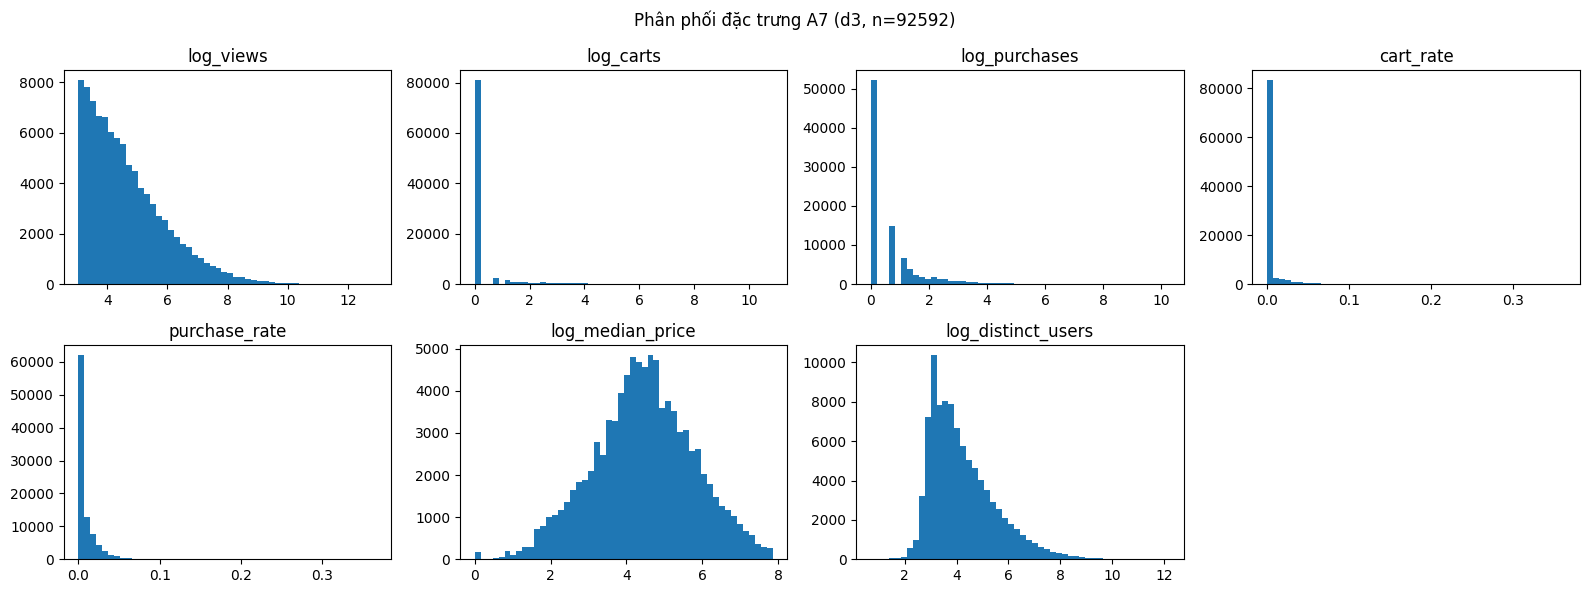

In [4]:
import matplotlib.pyplot as plt
pdf = products.select(*mc.FEATURES).toPandas()
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, mc.FEATURES):
    ax.hist(pdf[col], bins=50); ax.set_title(col)
axes.flat[-1].axis("off"); fig.suptitle(f"Phân phối đặc trưng A7 ({TAG}, n={N})"); fig.tight_layout(); plt.show()

## 4. Chuẩn hóa
Các đặc trưng đếm đã qua `log1p` ở bước Java (giảm lệch phải). K-Means dùng khoảng cách Euclidean nên mỗi đặc trưng được đưa về trung bình 0, độ lệch chuẩn 1 (`StandardScaler`), tránh để đặc trưng có thang đo lớn áp đảo.

In [5]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
assembled = VectorAssembler(inputCols=mc.FEATURES, outputCol="raw_features").transform(products)
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True).fit(assembled)
scaled = scaler.transform(assembled).cache()
scaled.count()
dict(zip(mc.FEATURES, zip(scaler.mean.toArray().round(4), scaler.std.toArray().round(4))))

{'log_views': (np.float64(4.6571), np.float64(1.2937)),
 'log_carts': (np.float64(0.2755), np.float64(0.8977)),
 'log_purchases': (np.float64(0.6676), np.float64(1.0325)),
 'cart_rate': (np.float64(0.003), np.float64(0.0114)),
 'purchase_rate': (np.float64(0.0075), np.float64(0.0133)),
 'log_median_price': (np.float64(4.4473), np.float64(1.3261)),
 'log_distinct_users': (np.float64(4.2072), np.float64(1.2587))}

## 5. Quét K × seed: inertia (trainingCost) và silhouette (squared Euclidean)

In [6]:
import pandas as pd
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", distanceMeasure="squaredEuclidean")
rows = []
with trace.stage("sweep"):
    for k in range(K_MIN, K_MAX + 1):
        for seed in SEEDS:
            t0 = time.perf_counter()
            model = KMeans(k=k, seed=seed, maxIter=MAX_ITER, initMode="k-means||").fit(scaled)
            pred = model.transform(scaled)
            sizes = [r["count"] for r in pred.groupBy("prediction").count().collect()]
            row = {"k": k, "seed": seed, "inertia": model.summary.trainingCost, "silhouette": evaluator.evaluate(pred),
                   "iterations": model.summary.numIter, "min_cluster": min(sizes), "max_cluster": max(sizes),
                   "fit_ms": round((time.perf_counter() - t0) * 1000)}
            rows.append(row)
            print(f"k={k:2d} seed={seed} inertia={row['inertia']:.1f} silhouette={row['silhouette']:.4f} iter={row['iterations']} sizes=[{row['min_cluster']}..{row['max_cluster']}] {row['fit_ms']} ms")
sweep = pd.DataFrame(rows)
summary = sweep.groupby("k").agg(inertia_mean=("inertia", "mean"), silhouette_mean=("silhouette", "mean"), silhouette_std=("silhouette", "std"), min_cluster=("min_cluster", "min"))
summary

[23:58:08] bắt đầu: sweep


k= 2 seed=1 inertia=441696.4 silhouette=0.6494 iter=28 sizes=[17356..75236] 10546 ms


k= 2 seed=2 inertia=441696.5 silhouette=0.6497 iter=36 sizes=[17328..75264] 7593 ms


k= 2 seed=3 inertia=441696.5 silhouette=0.6497 iter=11 sizes=[17328..75264] 2981 ms


k= 3 seed=1 inertia=348895.3 silhouette=0.5027 iter=24 sizes=[5466..60608] 4778 ms


...

k= 9 seed=3 inertia=180879.8 silhouette=0.3990 iter=50 sizes=[2025..23399] 6925 ms


k=10 seed=1 inertia=163893.3 silhouette=0.4150 iter=46 sizes=[448..23003] 6551 ms


k=10 seed=2 inertia=164213.5 silhouette=0.3763 iter=50 sizes=[1138..22372] 7056 ms


k=10 seed=3 inertia=164222.1 silhouette=0.4053 iter=50 sizes=[447..23205] 6863 ms
[00:01:16] xong: sweep (188311 ms)


,inertia_mean,silhouette_mean,silhouette_std,min_cluster
k,,,,
2,441696.453073,0.649565,0.000176,17328
3,348895.250624,0.502670,0.000000,5466
4,298541.851366,0.467886,0.097962,5283
5,260360.610167,0.437526,0.086852,3090
6,229899.665472,0.395532,0.015827,3070
7,211706.535704,0.390159,0.023155,1228
8,191526.603489,0.389397,0.005479,2704
9,185237.030630,0.377425,0.035790,1205
10,164109.625782,0.398864,0.020152,447


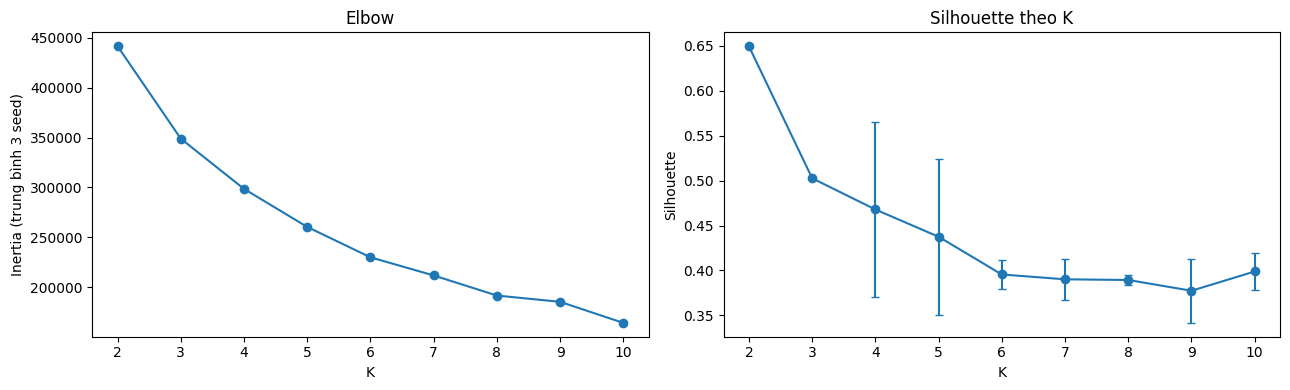

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(summary.index, summary.inertia_mean, marker="o"); a1.set_xlabel("K"); a1.set_ylabel("Inertia (trung bình 3 seed)"); a1.set_title("Elbow")
a2.errorbar(summary.index, summary.silhouette_mean, yerr=summary.silhouette_std, marker="o", capsize=3); a2.set_xlabel("K"); a2.set_ylabel("Silhouette"); a2.set_title("Silhouette theo K")
fig.tight_layout(); plt.show()

## 6. Chọn K theo quy tắc đã cố định và huấn luyện mô hình cuối

In [8]:
best_k = int(K_FIXED) if K_FIXED else int(summary.assign(r=summary.silhouette_mean.round(6)).sort_values(["r"], ascending=False).query("r == r.max()").index.min())
best_seed = SEEDS[0]
with trace.stage("final_model"):
    model = KMeans(k=best_k, seed=best_seed, maxIter=MAX_ITER, initMode="k-means||").fit(scaled)
    assigned = model.transform(scaled).withColumnRenamed("prediction", "cluster").cache()
final_silhouette = evaluator.setPredictionCol("cluster").evaluate(assigned); evaluator.setPredictionCol("prediction")
print(f"K chọn = {best_k} (seed {best_seed}); silhouette = {final_silhouette:.4f}; inertia = {model.summary.trainingCost:.1f}; số vòng lặp = {model.summary.numIter}")
assigned.groupBy("cluster").count().orderBy("cluster").toPandas().set_index("cluster").T

[00:01:17] bắt đầu: final_model


[00:01:21] xong: final_model (3572 ms)


K chọn = 2 (seed 1); silhouette = 0.6494; inertia = 441696.4; số vòng lặp = 28


cluster,0,1
count,17356,75236


## 7. So sánh baseline

In [9]:
import numpy as np
from pyspark.ml.functions import vector_to_array
from pyspark.ml.linalg import Vectors
from pyspark.sql.window import Window
with trace.stage("baselines"):
    matrix = np.array(scaled.select(vector_to_array("features").alias("v")).toPandas()["v"].tolist())
    rng = np.random.default_rng(best_seed)
    shuffled = matrix.copy()
    for j in range(shuffled.shape[1]):
        shuffled[:, j] = rng.permutation(shuffled[:, j])
    shuffled_df = spark.createDataFrame([(Vectors.dense(r),) for r in shuffled], ["features"]).cache()
    shuffled_sil = evaluator.evaluate(KMeans(k=best_k, seed=best_seed, maxIter=MAX_ITER).fit(shuffled_df).transform(shuffled_df))
    price_groups = scaled.withColumn("prediction", F.ntile(best_k).over(Window.orderBy("log_median_price")) - 1)
    price_sil = evaluator.evaluate(price_groups)
baselines = pd.DataFrame({"silhouette": {"K-Means (mô hình)": final_silhouette, "Baseline 1: xáo độc lập từng cột": shuffled_sil, f"Baseline 2: {best_k} nhóm theo phân vị giá": price_sil}})
baselines

[00:01:22] bắt đầu: baselines


[00:01:32] xong: baselines (9785 ms)


,silhouette
K-Means (mô hình),0.649361
Baseline 1: xáo độc lập từng cột,0.316117
Baseline 2: 2 nhóm theo phân vị giá,0.183198


## 8. Hồ sơ cụm (để diễn giải bằng thống kê)
Trung bình đặc trưng gốc theo cụm và 3 `category_root` phổ biến nhất trong mỗi cụm (category **không** dùng khi huấn luyện).

In [10]:
profile = (assigned.groupBy("cluster").agg(
        F.count(F.lit(1)).alias("products"),
        *[F.round(F.avg(c), 3).alias(f"mean_{c}") for c in ["views", "carts", "purchases", "distinct_users", "median_price"]],
        F.round(F.avg(F.col("carts") / F.col("views")), 4).alias("mean_cart_rate"),
        F.round(F.avg(F.col("purchases") / F.col("views")), 4).alias("mean_purchase_rate"),
        F.round(F.avg((F.col("purchases") > 0).cast("double")), 3).alias("share_with_purchase"))
    .orderBy("cluster").toPandas().set_index("cluster"))
roots = (assigned.groupBy("cluster", F.coalesce("category_root", F.lit("__UNKNOWN__")).alias("root")).count()
         .withColumn("rank", F.row_number().over(Window.partitionBy("cluster").orderBy(F.desc("count")))).where("rank <= 3")
         .orderBy("cluster", "rank").toPandas())
profile["top_category_roots"] = roots.groupby("cluster").apply(lambda g: "; ".join(f"{r.root}:{r['count']}" for _, r in g.iterrows()))
profile

C:\Users\Hi\AppData\Local\Temp\ipykernel_24064\2495863873.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  profile["top_category_roots"] = roots.groupby("cluster").apply(lambda g: "; ".join(f"{r.root}:{r['count']}" for _, r in g.iterrows()))


,products,mean_views,mean_carts,mean_purchases,mean_distinct_users,mean_median_price,mean_cart_rate,mean_purchase_rate,share_with_purchase,top_category_roots
cluster,,,,,,,,,,
0,17356,1911.750,53.111,40.463,1055.471,215.360,0.0127,0.0158,0.985,__UNKNOWN__:7783; appliances:2824; electronics...
1,75236,93.965,0.059,0.511,61.044,188.091,0.0007,0.0056,0.309,__UNKNOWN__:39368; electronics:7652; apparel:6482


In [11]:
centers = pd.DataFrame(model.clusterCenters(), columns=mc.FEATURES).round(3)
centers.index.name = "cluster"
print("Tâm cụm trong không gian đã chuẩn hóa (đơn vị: độ lệch chuẩn so với trung bình):")
centers

Tâm cụm trong không gian đã chuẩn hóa (đơn vị: độ lệch chuẩn so với trung bình):


,log_views,log_carts,log_purchases,cart_rate,purchase_rate,log_median_price,log_distinct_users
cluster,,,,,,,
0,1.534,1.164,1.608,0.856,0.622,0.161,1.492
1,-0.354,-0.269,-0.371,-0.198,-0.144,-0.037,-0.344


## 9. Lưu kết quả lên HDFS: model Spark (scaler + K-Means), `model.json` cho suy luận ngoài Spark, `metrics.json`, `metadata.json`; kiểm tra suy luận numpy

In [12]:
with trace.stage("write_outputs"):
    scaler.write().save(mc.hdfs(f"{OUT}/scaler_model"))          # Spark MLlib StandardScalerModel
    model.write().save(mc.hdfs(f"{OUT}/kmeans_model"))           # Spark MLlib KMeansModel
    (assigned.select("product_id", "cluster", *mc.FEATURES, "views", "carts", "purchases", "median_price", "distinct_users", "category_code", "category_root", "brand")
     .write.mode("errorifexists").parquet(mc.hdfs(f"{OUT}/assignments")))
model_json = {"type": "kmeans", "runId": RUN_ID, "featuresRunId": FEATURES_RUN_ID, "k": best_k, "seed": best_seed, "features": mc.FEATURES,
              "scalerMean": scaler.mean.toArray().tolist(), "scalerStd": scaler.std.toArray().tolist(), "centers": [c.tolist() for c in model.clusterCenters()]}
LOCAL.mkdir(parents=True, exist_ok=True)
(LOCAL / "model.json").write_text(json.dumps(model_json, indent=2), encoding="utf-8")
mc.write_hdfs_json(spark, f"{OUT}/model.json", model_json)
from datetime import datetime, timezone
distribution = {int(r["cluster"]): int(r["count"]) for r in assigned.groupBy("cluster").count().collect()}
metrics_json = {"selectionRule": "fixed K" if K_FIXED else "max mean silhouette over seeds, tie -> smaller K",
                "sweep": summary.reset_index().to_dict(orient="records"), "k": best_k, "silhouette": final_silhouette,
                "inertia": model.summary.trainingCost, "iterations": model.summary.numIter, "clusterSizes": distribution}
metadata_json = {"model_type": "clustering", "algorithm": "k-means (Spark MLlib, k-means||)", "run_id": RUN_ID,
                 "training_time": datetime.now(timezone.utc).isoformat(), "dataset": {"tag": TAG, "featuresRunId": FEATURES_RUN_ID, "products": N},
                 "features": mc.FEATURES, "feature_preprocessing": "log1p (Java A7) + StandardScaler(withMean, withStd) (Spark MLlib)",
                 "hyperparameters": {"k": best_k, "seed": best_seed, "maxIter": MAX_ITER, "initMode": "k-means||"},
                 "metrics": {"silhouette": final_silhouette, "inertia": model.summary.trainingCost},
                 "model_path": OUT, "status": "trained"}
for name, value in (("metrics.json", metrics_json), ("metadata.json", metadata_json)):
    (LOCAL / name).write_text(json.dumps(value, indent=2, default=str), encoding="utf-8")
    mc.write_hdfs_json(spark, f"{OUT}/{name}", value)
check = assigned.select(*mc.FEATURES, "cluster").toPandas()
x = (check[mc.FEATURES].to_numpy() - np.array(model_json["scalerMean"])) / np.array(model_json["scalerStd"])
numpy_pred = ((x[:, None, :] - np.array(model_json["centers"])[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)
parity = float((numpy_pred == check["cluster"].to_numpy()).mean())
print(f"Parity numpy vs Spark trên {len(check)} sản phẩm: {parity:.6f}")
assert parity == 1.0

[00:01:34] bắt đầu: write_outputs


[00:01:39] xong: write_outputs (5186 ms)


Parity numpy vs Spark trên 92592 sản phẩm: 1.000000


## 10. E7 — Thuật toán lặp và cache (kiểm chứng luận điểm Chương 1)
`pyspark.ml.KMeans` tự persist dữ liệu vào nếu chưa cache, nên phép so sánh dùng API RDD `pyspark.mllib.clustering.KMeans`
với **cùng K, seed, số vòng lặp cố định (epsilon = 0)**. Mỗi chế độ: 1 lần warmup (không tính) + 3 lần đo; báo median (min–max).
Thời gian `count()` để nạp cache được báo riêng. Dữ liệu vào đọc từ Parquet trên HDFS.

In [13]:
from pyspark.mllib.clustering import KMeans as RddKMeans
e7_rows = []
with trace.stage("e7"):
    for repeat in range(E7_REPEATS + 1):
        for mode in ("no_cache", "cache"):
            points = (spark.read.parquet(mc.hdfs(f"{mc.FEATURES_ROOT}/run_id={FEATURES_RUN_ID}")).select(*mc.FEATURES).rdd
                      .map(lambda r, m=scaler.mean.toArray(), s=scaler.std.toArray(): (np.array(r, dtype=float) - m) / s))
            count_ms = None
            if mode == "cache":
                t0 = time.perf_counter(); points = points.cache(); points.count(); count_ms = round((time.perf_counter() - t0) * 1000)
            t0 = time.perf_counter()
            RddKMeans.train(points, best_k, maxIterations=E7_ITERATIONS, initializationMode="random", seed=best_seed, epsilon=0.0)
            fit_ms = round((time.perf_counter() - t0) * 1000)
            e7_rows.append({"repeat": repeat, "warmup": repeat == 0, "mode": mode, "fit_ms": fit_ms, "cache_count_ms": count_ms})
            print(f"repeat={repeat}{' (warmup)' if repeat == 0 else ''} mode={mode:8s} fit={fit_ms} ms cache_count={count_ms}")
            if mode == "cache":
                points.unpersist()
e7 = pd.DataFrame(e7_rows)
e7_summary = e7[~e7.warmup].groupby("mode").fit_ms.agg(["median", "min", "max"])
e7_summary

[00:01:40] bắt đầu: e7


repeat=0 (warmup) mode=no_cache fit=8138 ms cache_count=None


repeat=0 (warmup) mode=cache    fit=4413 ms cache_count=7627


repeat=1 mode=no_cache fit=6954 ms cache_count=None


repeat=1 mode=cache    fit=5932 ms cache_count=10298


repeat=2 mode=no_cache fit=5753 ms cache_count=None


repeat=2 mode=cache    fit=4849 ms cache_count=5701


repeat=3 mode=no_cache fit=5770 ms cache_count=None


repeat=3 mode=cache    fit=4387 ms cache_count=5706
[00:02:57] xong: e7 (77130 ms)


,median,min,max
mode,,,
cache,4849.0,4387,5932
no_cache,5770.0,5753,6954


## 11. Lưu vết lần chạy

In [14]:
trace.record["environment"] = ENV
trace.record["metrics"] = {
    "products": N, "selectionRule": "max mean silhouette over seeds, tie -> smaller K", "bestK": best_k, "bestSeed": best_seed,
    "finalSilhouette": final_silhouette, "finalInertia": model.summary.trainingCost, "iterations": model.summary.numIter,
    "baselineShuffledColumnsSilhouette": shuffled_sil, "baselinePriceQuantileSilhouette": price_sil, "numpyParity": parity,
    "e7": e7_summary.to_dict(orient="index"), "e7Iterations": E7_ITERATIONS}
sweep.to_csv(LOCAL / "kmeans-sweep.csv", index=False); profile.to_csv(LOCAL / "kmeans-profile.csv"); e7.to_csv(LOCAL / "e7.csv", index=False)
mc.write_hdfs_text(spark, f"{OUT}/sweep.csv", sweep.to_csv(index=False, lineterminator="\n"))     # cho bước publish serving
mc.write_hdfs_text(spark, f"{OUT}/profile.csv", profile.reset_index().to_csv(index=False, lineterminator="\n"))
record = trace.finish(LOCAL)
mc.write_hdfs_json(spark, f"{OUT}/_run.json", record)
print(json.dumps(record["metrics"], indent=2, default=str))
print("Kết quả cục bộ:", LOCAL, "| HDFS:", OUT)

{
  "products": 92592,
  "selectionRule": "max mean silhouette over seeds, tie -> smaller K",
  "bestK": 2,
  "bestSeed": 1,
  "finalSilhouette": 0.6493609062950365,
  "finalInertia": 441696.4421249071,
  "iterations": 28,
  "baselineShuffledColumnsSilhouette": 0.31611670749910625,
  "baselinePriceQuantileSilhouette": 0.18319825136387252,
  "numpyParity": 1.0,
  "e7": {
    "cache": {
      "median": 4849.0,
      "min": 4387,
      "max": 5932
    },
    "no_cache": {
      "median": 5770.0,
      "min": 5753,
      "max": 6954
    }
  },
  "e7Iterations": 20
}
Kết quả cục bộ: E:\PTIT\PTIT Project Management\DLL\New\ptit_bigdata\results\ml\20261006-235739-b0376ef-d3 | HDFS: /data/ecommerce/ml/kmeans/run_id=20261006-235739-b0376ef-d3


In [15]:
spark.stop()